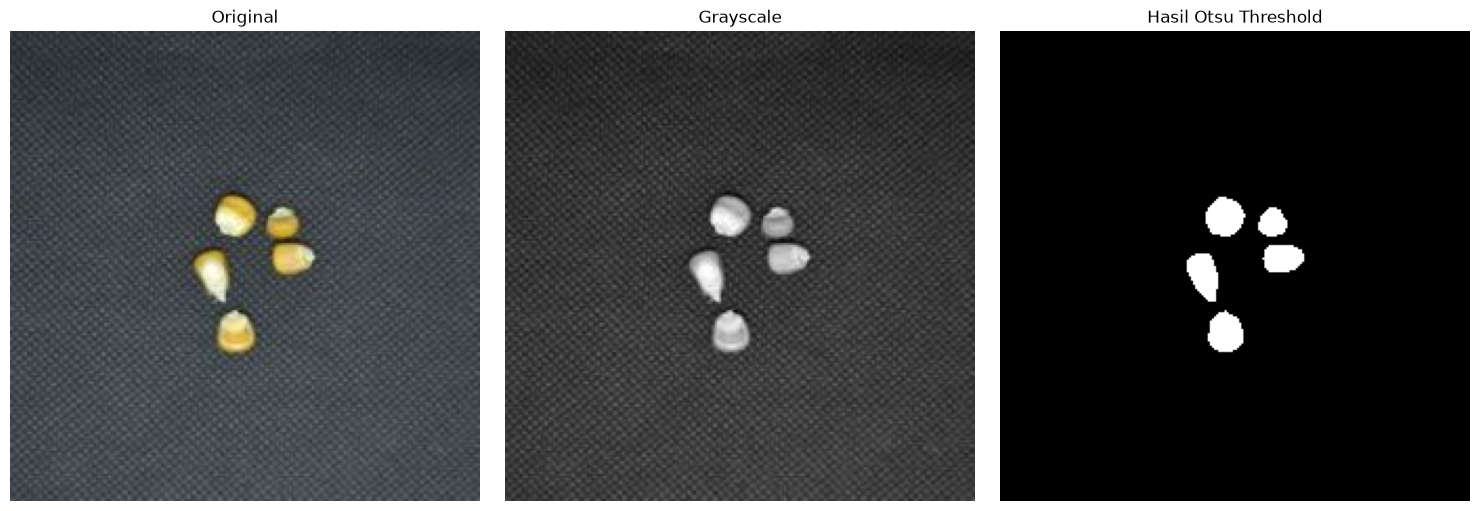

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "../data/raw/sehat/normal_004.JPG"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1: ubah ke grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2: mengurangi noise dengan Gaussian Blur sebelum thresholding
# (5,5) = ukuran kernel blur, 0 = standar deviasi dihitung otomatis oleh OpenCV
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 3: Otsu thresholding
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# hasil
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[1].imshow(gray, cmap='gray')
axes[1].set_title("Grayscale")
axes[2].imshow(thresh, cmap='gray')
axes[2].set_title("Hasil Otsu Threshold")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

Jumlah kontur terdeteksi: 5
Jumlah biji valid (setelah filter noise): 5


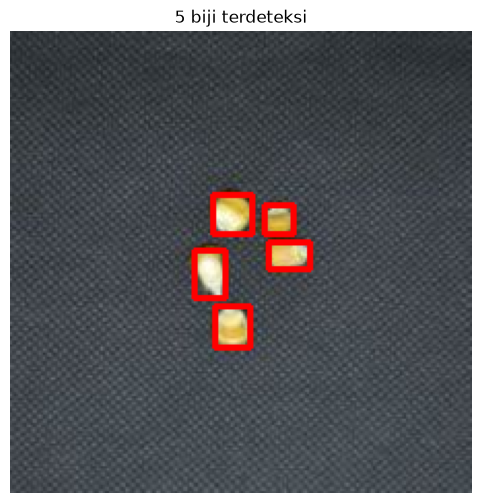

In [4]:
# 4: mencari kontur (garis tepi) dari tiap blob putih di hasil threshold
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Jumlah kontur terdeteksi: {len(contours)}")

# 5: memfilter kontur yang terlalu kecil
MIN_AREA = 100  # ambang batas minimal luas piksel
biji_contours = [c for c in contours if cv2.contourArea(c) > MIN_AREA]

print(f"Jumlah biji valid (setelah filter noise): {len(biji_contours)}")

# 6: menggambar bounding box (kotak pembatas) di sekitar tiap biji untuk verifikasi visual
img_with_boxes = img_rgb.copy()
for c in biji_contours:
    x, y, w, h = cv2.boundingRect(c)  # (x,y) = pojok kiri-atas kotak, w,h = lebar & tinggi kotak
    cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (255, 0, 0), 2)  # kotak merah, tebal 2px

plt.figure(figsize=(6, 6))
plt.imshow(img_with_boxes)
plt.title(f"{len(biji_contours)} biji terdeteksi")
plt.axis('off')
plt.show()

In [ ]:
# Diagnosis: menampilkan luas semua kontur SEBELUM difilter, urut dari kecil ke besar
semua_area = sorted([cv2.contourArea(c) for c in contours])
print("Luas semua kontur terdeteksi (piksel):")
print(semua_area)

Luas semua kontur terdeteksi (piksel):
[127.5, 190.0, 220.0, 233.0, 243.0]


In [5]:
import numpy as np
import cv2
import os
import pandas as pd

# membuat folder untuk menyimpan hasil crop
os.makedirs("../data/cropped/sehat", exist_ok=True)
os.makedirs("../data/cropped/terkontaminasi", exist_ok=True)

MIN_AREA = 100
MARGIN = 3

def deteksi_dan_crop(img_path, label, folder_tujuan, sumber_nama):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological Opening: memutus jembatan tipis & buang noise kecil,
    # sambil pertahankan ukuran objek yang selamat mendekati aslinya
    kernel_morph = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_morph, iterations=2)

    contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter DUA arah: buang yang terlalu kecil (noise) DAN yang terlalu besar
    # (artefak background atau tumpukan banyak biji menyatu)
    MIN_AREA = 100
    MAX_AREA = 700  # berdasarkan biji valid terbesar yang pernah kita lihat (~547px), + margin
    biji_contours = [c for c in contours if MIN_AREA < cv2.contourArea(c) < MAX_AREA]

    hasil = []
    h_img, w_img = img.shape[:2]

    for idx, c in enumerate(biji_contours):
        x, y, w, h = cv2.boundingRect(c)
        x1 = max(x - MARGIN, 0)
        y1 = max(y - MARGIN, 0)
        x2 = min(x + w + MARGIN, w_img)
        y2 = min(y + h + MARGIN, h_img)

        crop = img[y1:y2, x1:x2]

        nama_file_crop = f"{sumber_nama}_biji{idx+1}.jpg"
        path_simpan = os.path.join(folder_tujuan, nama_file_crop)
        cv2.imwrite(path_simpan, crop)

        hasil.append({
            "filename": nama_file_crop,
            "source_file": sumber_nama,
            "label": label,
            "area_piksel": cv2.contourArea(c),
            "width": x2 - x1,
            "height": y2 - y1
        })

    return hasil

manifest = []

for label, path_folder, folder_tujuan in [
    ("sehat", "../data/raw/sehat", "../data/cropped/sehat"),
    ("terkontaminasi", "../data/raw/terkontaminasi", "../data/cropped/terkontaminasi"),
]:
    daftar_file = os.listdir(path_folder)
    for nama_file in daftar_file:
        img_path = os.path.join(path_folder, nama_file)
        sumber_nama = os.path.splitext(nama_file)[0]
        hasil_crop = deteksi_dan_crop(img_path, label, folder_tujuan, sumber_nama)
        manifest.extend(hasil_crop)

df_manifest = pd.DataFrame(manifest)
df_manifest.to_csv("../data/manifest_crop.csv", index=False)

print(f"Total crop dihasilkan: {len(df_manifest)}")
print(df_manifest["label"].value_counts())
print("\nStatistik luas piksel per crop:")
print(df_manifest["area_piksel"].describe())

Total crop dihasilkan: 105
label
terkontaminasi    64
sehat             41
Name: count, dtype: int64

Statistik luas piksel per crop:
count    105.000000
mean     274.347619
std       82.688047
min      101.500000
25%      222.500000
50%      275.000000
75%      322.500000
max      589.000000
Name: area_piksel, dtype: float64


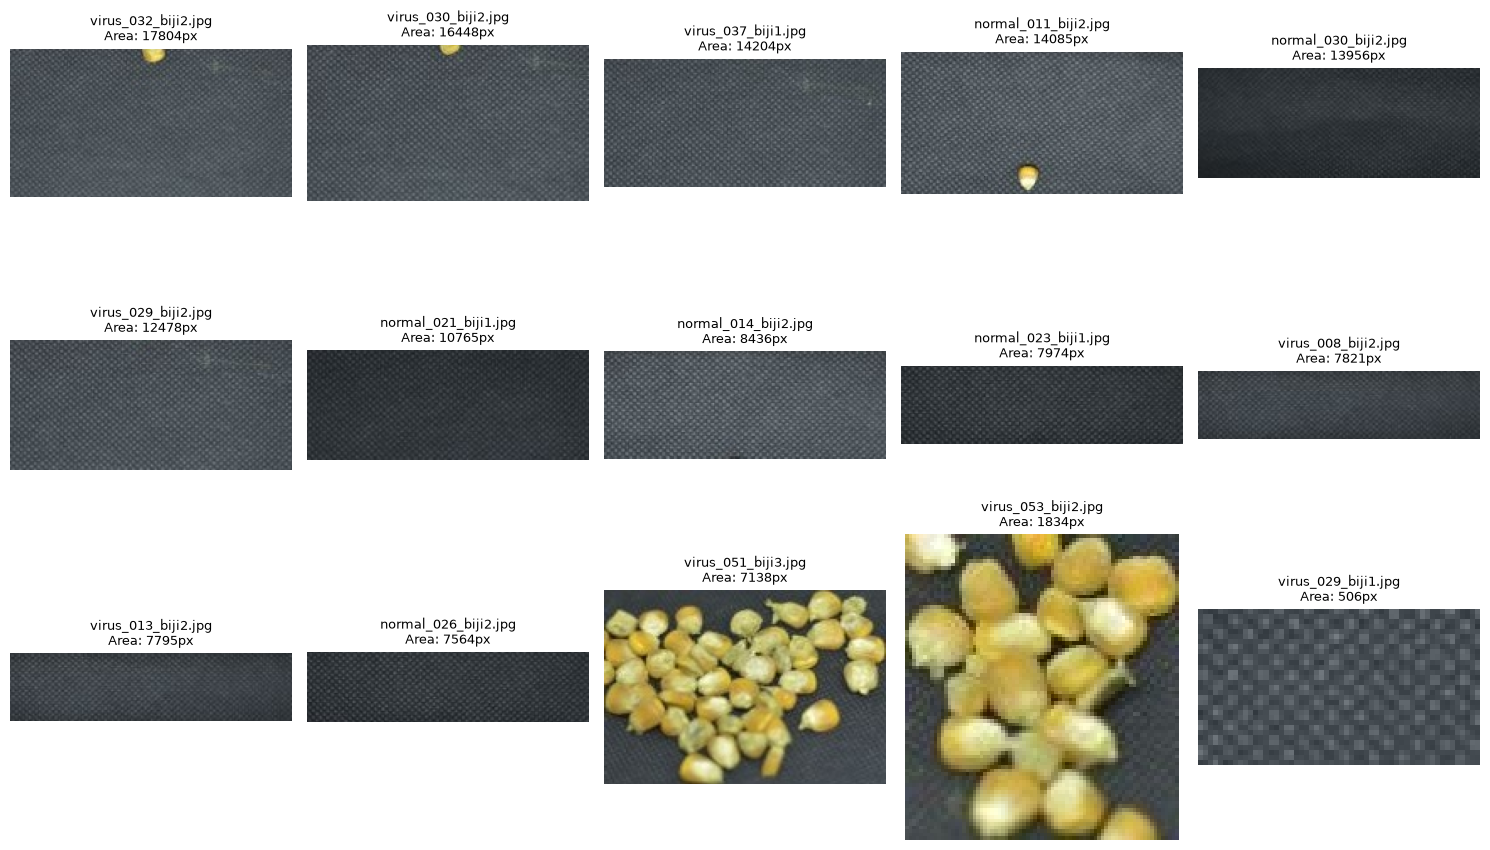

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os

# mengurutkan manifest berdasarkan luas piksel, dari yang terbesar
df_sorted = df_manifest.sort_values("area_piksel", ascending=False)

top_n = 15
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i in range(top_n):
    row = df_sorted.iloc[i]
    folder = "../data/cropped/sehat" if row["label"] == "sehat" else "../data/cropped/terkontaminasi"
    img_path = os.path.join(folder, row["filename"])
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{row['filename']}\nArea: {row['area_piksel']:.0f}px", fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# menghitung rasio isi kotak
df_manifest["fill_ratio"] = df_manifest["area_piksel"] / (df_manifest["width"] * df_manifest["height"])

# mengurutkan dari rasio terkecil
df_sorted_fill = df_manifest.sort_values("fill_ratio", ascending=True)

print("10 crop dengan fill_ratio terendah (kandidat noise/crease):")
print(df_sorted_fill[["filename", "area_piksel", "width", "height", "fill_ratio"]].head(10))

print("\nStatistik fill_ratio keseluruhan:")
print(df_manifest["fill_ratio"].describe())

10 crop dengan fill_ratio terendah (kandidat noise/crease):
                 filename  area_piksel  width  height  fill_ratio
33   normal_021_biji1.jpg        106.0     29      21    0.174056
54    virus_008_biji1.jpg        117.5     35      19    0.176692
24   normal_014_biji1.jpg        111.5     33      19    0.177831
20   normal_011_biji1.jpg        176.0     35      25    0.201143
109   virus_052_biji1.jpg        547.0     50      44    0.248636
102   virus_050_biji1.jpg       1023.5     58      69    0.255747
106   virus_051_biji4.jpg        126.0     22      20    0.286364
10   normal_004_biji4.jpg        127.5     20      20    0.318750
12   normal_005_biji1.jpg        162.0     22      23    0.320158
23   normal_013_biji1.jpg        168.5     25      21    0.320952

Statistik fill_ratio keseluruhan:
count    115.000000
mean       0.420531
std        0.130256
min        0.174056
25%        0.366019
50%        0.399316
75%        0.421874
max        0.854632
Name: fill_ratio, d

In [5]:
# Aspect ratio = sisi terpanjang dibagi sisi terpendek dari bounding box
# Nilai mendekati 1 = kotak proporsional (persegi/oval wajar)
# Nilai tinggi (misal >3) = kotak memanjang ke satu arah
df_manifest["aspect_ratio"] = (
    df_manifest[["width", "height"]].max(axis=1) / df_manifest[["width", "height"]].min(axis=1)
)

df_besar = df_manifest[df_manifest["area_piksel"] > 3000].sort_values("area_piksel", ascending=False)
print(df_besar[["filename", "area_piksel", "width", "height", "aspect_ratio", "fill_ratio"]].to_string())

                 filename  area_piksel  width  height  aspect_ratio  fill_ratio
80    virus_030_biji1.jpg      26035.5    224     136      1.647059    0.854632
82    virus_032_biji1.jpg      24774.5    224     136      1.647059    0.813239
21   normal_011_biji2.jpg      22221.5    224     140      1.600000    0.708594
79    virus_029_biji1.jpg      22095.5    224     131      1.709924    0.752982
87    virus_037_biji1.jpg      21036.0    224     116      1.931034    0.809575
34   normal_021_biji2.jpg      17864.0    224     122      1.836066    0.653689
46   normal_030_biji2.jpg      16034.5    224      90      2.488889    0.795362
26   normal_014_biji3.jpg      15636.0    224     104      2.153846    0.671188
37   normal_023_biji2.jpg      12021.5    224      66      3.393939    0.813143
41   normal_026_biji2.jpg      11309.5    224      66      3.393939    0.764982
105   virus_051_biji3.jpg      10176.5    188     120      1.566667    0.451086
63    virus_013_biji2.jpg       9813.0  

In [6]:
# menghitung berapa biji terdeteksi per foto sumber (source_file)
jumlah_per_foto = df_manifest.groupby("source_file").size().sort_values(ascending=False)

print("Distribusi jumlah biji per foto sumber:")
print(jumlah_per_foto.describe())

print("\nFoto dengan biji terbanyak (kandidat 'tumpukan'):")
print(jumlah_per_foto.head(10))

tumpukan = jumlah_per_foto[jumlah_per_foto > 5]
print(f"\nJumlah foto kandidat 'tumpukan' (>5 biji terdeteksi): {len(tumpukan)}")
print(f"Total biji dari foto-foto tumpukan ini: {tumpukan.sum()}")

Distribusi jumlah biji per foto sumber:
count    83.000000
mean      1.385542
std       0.960581
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       6.000000
dtype: float64

Foto dengan biji terbanyak (kandidat 'tumpukan'):
source_file
virus_051     6
virus_053     5
normal_004    5
normal_002    4
virus_008     3
normal_014    3
normal_005    3
normal_021    2
normal_001    2
normal_011    2
dtype: int64

Jumlah foto kandidat 'tumpukan' (>5 biji terdeteksi): 1
Total biji dari foto-foto tumpukan ini: 6


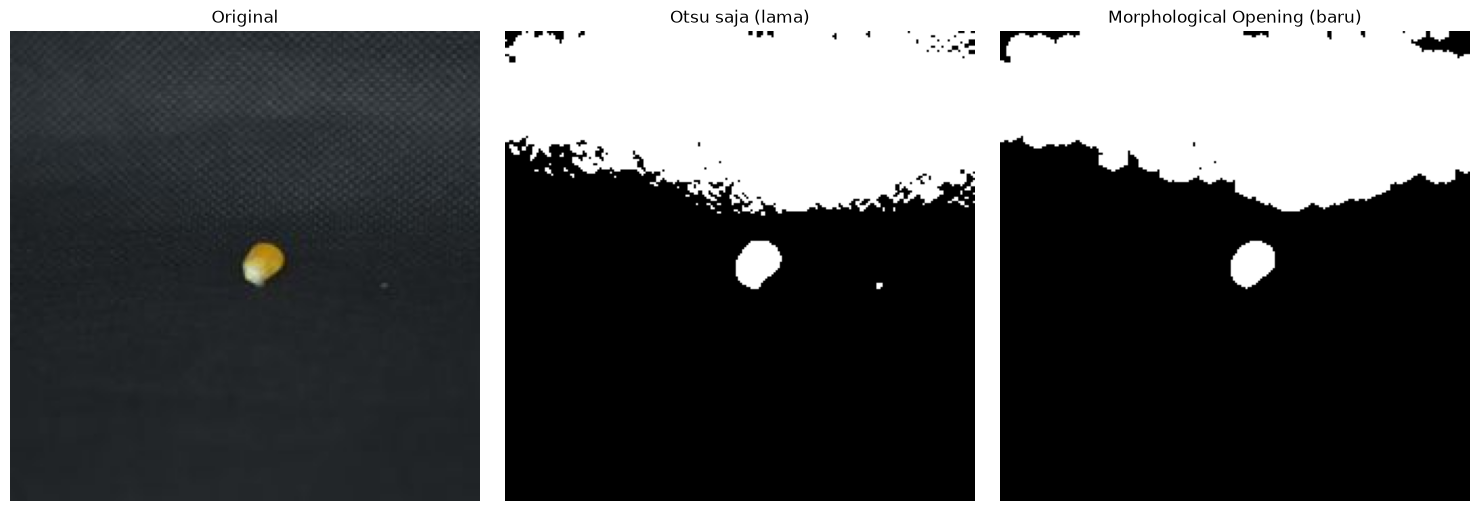

Jumlah kontur: 3
Luas tiap kontur: [22.0, 321.0, 14970.0]


In [4]:
# Uji coba pada 1 foto yang masih bermasalah
img_path_test = "../data/raw/sehat/normal_030.JPG"
img_test = cv2.imread(img_path_test)
img_test_rgb = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)
gray_test = cv2.cvtColor(img_test, cv2.COLOR_BGR2GRAY)
blur_test = cv2.GaussianBlur(gray_test, (5, 5), 0)
_, thresh_test = cv2.threshold(blur_test, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Structuring element bentuk elips (lebih halus dari persegi untuk objek bulat/oval seperti biji)
kernel_morph = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# MORPH_OPEN = erode lalu dilate dengan kernel yang sama
# Erode memutus jembatan tipis, dilate mengembalikan ukuran objek yang selamat mendekati semula
opened_test = cv2.morphologyEx(thresh_test, cv2.MORPH_OPEN, kernel_morph, iterations=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_test_rgb)
axes[0].set_title("Original")
axes[1].imshow(thresh_test, cmap='gray')
axes[1].set_title("Otsu saja (lama)")
axes[2].imshow(opened_test, cmap='gray')
axes[2].set_title("Morphological Opening (baru)")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# Cek jumlah & luas kontur hasil metode baru
contours_test, _ = cv2.findContours(opened_test, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
luas_test = sorted([cv2.contourArea(c) for c in contours_test])
print(f"Jumlah kontur: {len(contours_test)}")
print(f"Luas tiap kontur: {luas_test}")

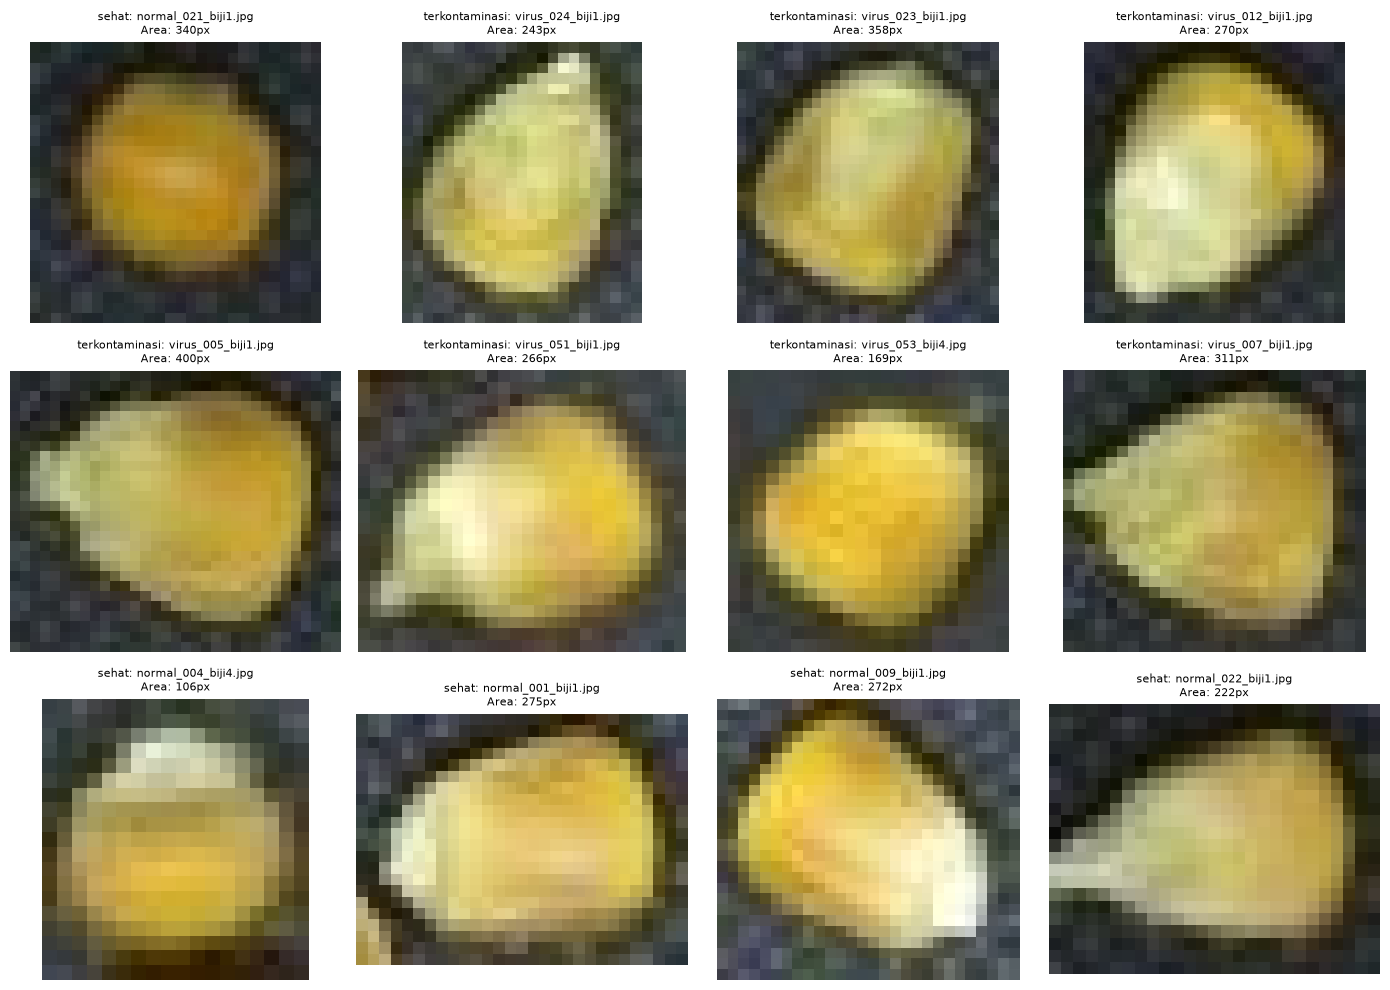

In [6]:
import random

# Ambil 12 sampel ACAK dari seluruh 105 crop (bukan diurutkan), campur kedua label
random.seed(42)  # supaya hasilnya konsisten kalau dijalankan ulang, bukan acak berbeda tiap kali
sampel_acak = df_manifest.sample(n=12, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(sampel_acak.iterrows()):
    folder = "../data/cropped/sehat" if row["label"] == "sehat" else "../data/cropped/terkontaminasi"
    img_path = os.path.join(folder, row["filename"])
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{row['label']}: {row['filename']}\nArea: {row['area_piksel']:.0f}px", fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()